# Santander Cycles: Demand and Rebalancing Analysis

**Business question:** where is Santander Cycles demand most imbalanced, and how should bikes be rebalanced across the network?

Data: TfL's public cycle hire trip data, 1 April to 31 May 2026, about 1.67 million trips across 803 stations. See [`sql/00_setup.md`](../sql/00_setup.md) for why this two-month window rather than the full multi-year archive.

## Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from portfolio import PALETTE, apply_house_style
from portfolio.paths import project_dir

apply_house_style()
pd.set_option("display.max_columns", None)

PROJECT = project_dir("01-tfl-cycling")
SQL = PROJECT / "sql"
FIG = PROJECT / "outputs/figures"

con = duckdb.connect(str(PROJECT / "data/processed/tfl_cycling.duckdb"))

def run(sql_file):
    return con.execute((SQL / sql_file).read_text()).fetchdf()

## 1. Data overview

In [2]:
run("01_data_overview.sql")

,trips,first_trip,last_trip,distinct_start_stations,distinct_bikes,avg_duration_min,median_duration_min
0,1665849,2026-04-01,2026-06-01,803,12041,22.0,13.6


1.67 million trips, 803 stations, over 12,000 individual bikes tracked. Average trip is 22.0 minutes but the median is only 13.6, a right-skewed distribution: most trips are short hops, with a longer tail of leisure rides pulling the average up.

## 2. When does demand actually happen?

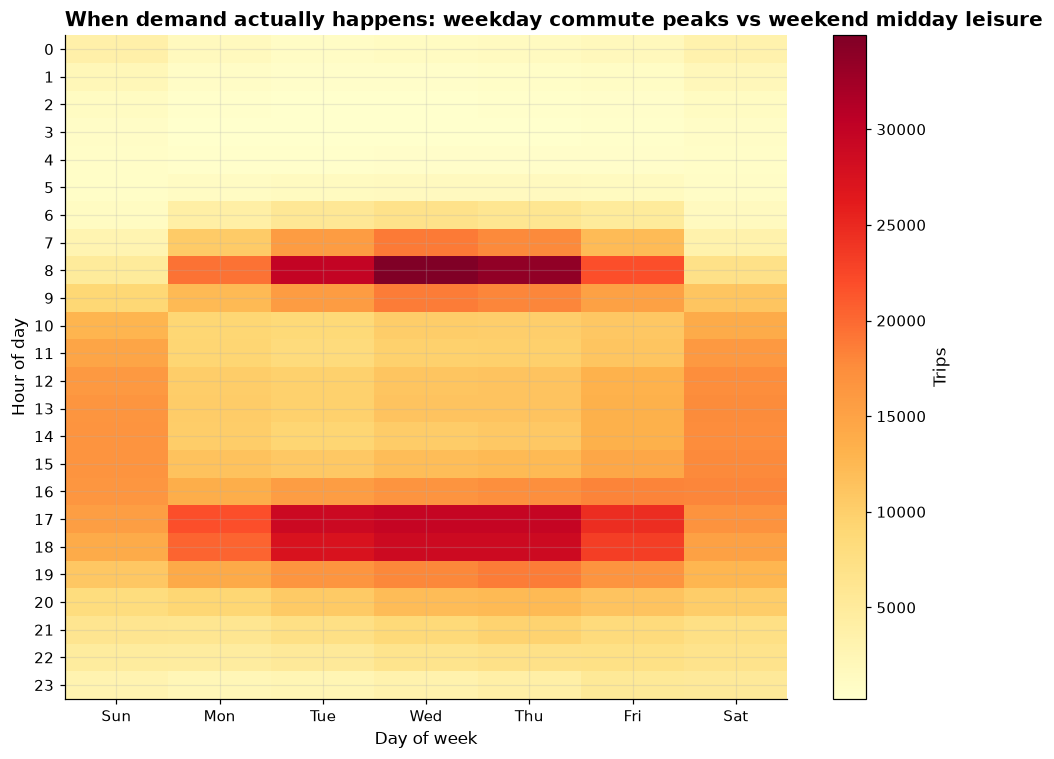

In [3]:
demand = run("02_demand_by_hour_dow.sql")
pivot = demand.pivot(index="hour_of_day", columns="dow_num", values="trips")
day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
pivot = pivot.reindex(columns=range(7)); pivot.columns = day_labels

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(7)); ax.set_xticklabels(day_labels)
ax.set_yticks(range(24)); ax.set_yticklabels(range(24))
ax.set_xlabel("Day of week"); ax.set_ylabel("Hour of day")
ax.set_title("When demand actually happens: weekday commute peaks vs weekend midday leisure")
fig.colorbar(im, ax=ax, label="Trips")
fig.tight_layout()
fig.savefig(FIG / "01_demand_heatmap.png")
plt.show()

**Finding:** a textbook commute pattern on weekdays, sharp peaks at 8am and 5-6pm, with the evening peak the larger of the two. Weekends show a single broad hump across the middle of the day instead, consistent with leisure riding rather than commuting. Any rebalancing schedule has to treat weekdays and weekends as genuinely different operating patterns, not one average day.

## 3. Which stations are chronically out of balance?

This is the core business question. A station where bikes reliably pile up will run out of docking space; a station where bikes reliably drain out will run out of bikes. Both need a rebalancing van, not just riders sorting it out naturally.

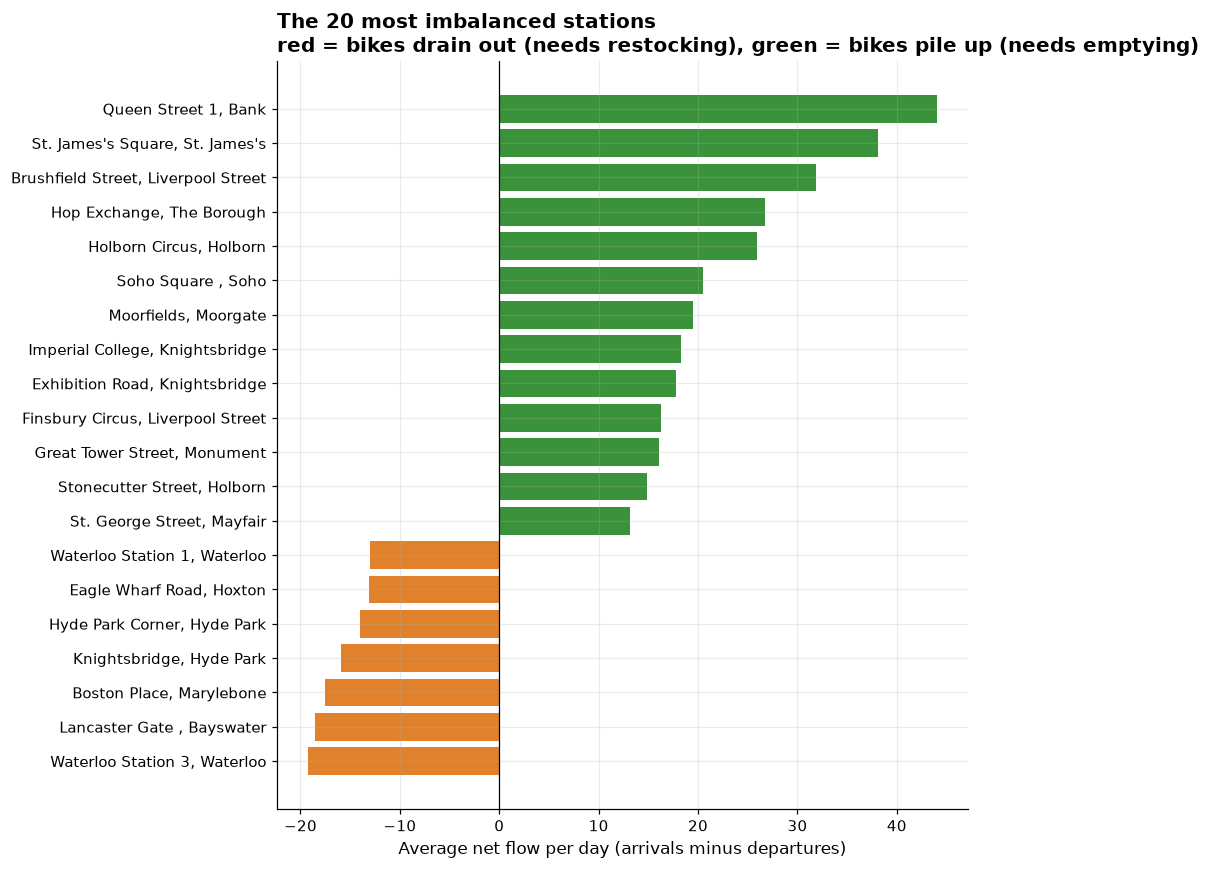

In [4]:
imb = run("03_station_imbalance.sql").sort_values("avg_net_flow_per_day")
fig, ax = plt.subplots(figsize=(9, 8))
colors = [PALETTE[1] if v < 0 else PALETTE[2] for v in imb["avg_net_flow_per_day"]]
ax.barh(imb["station"], imb["avg_net_flow_per_day"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Average net flow per day (arrivals minus departures)")
ax.set_title("The 20 most imbalanced stations\nred = bikes drain out (needs restocking), green = bikes pile up (needs emptying)")
fig.tight_layout()
fig.savefig(FIG / "02_station_imbalance.png")
plt.show()

**Finding:** the imbalance is not random, it follows the commute. Stations that fill up (green) are almost all in the City of London financial district: Bank, Liverpool Street, Moorgate, Holborn, Monument. Riders arrive by bike in the morning for work and don't ride back out until evening, so bikes accumulate all day. Stations that drain (red) are major rail termini and park/leisure areas: Waterloo (both major docks), Hyde Park Corner, Knightsbridge, Lancaster Gate. People arrive by train or on foot and take a bike onward, or start a leisure ride from a park, with nothing returning to replace what left.

The practical implication: a rebalancing van route that moves bikes from the City stations (where they pile up during the day) to the termini and park stations (where they drain) would directly relieve the network's biggest, most predictable pressure points, timed for the late-morning and early-afternoon lull between the two commute peaks.

## 4. Busiest stations overall

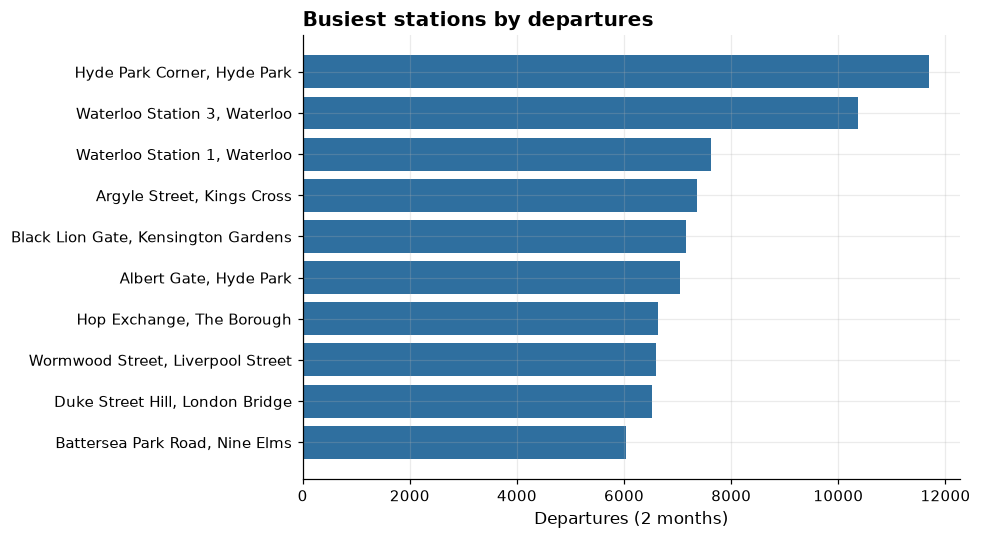

In [5]:
top = run("04_top_stations_and_routes.sql").sort_values("departures")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["station"], top["departures"], color=PALETTE[0])
ax.set_xlabel("Departures (2 months)")
ax.set_title("Busiest stations by departures")
fig.tight_layout()
fig.savefig(FIG / "03_top_stations.png")
plt.show()

**Finding:** Hyde Park Corner and both Waterloo Station docks lead the network in raw activity. These are also among the most imbalanced stations (section 3), which compounds the problem: high volume and high imbalance together mean the absolute number of bikes needing to be moved each day is large, not just the percentage.

## 5. Are e-bikes used differently from classic bikes?

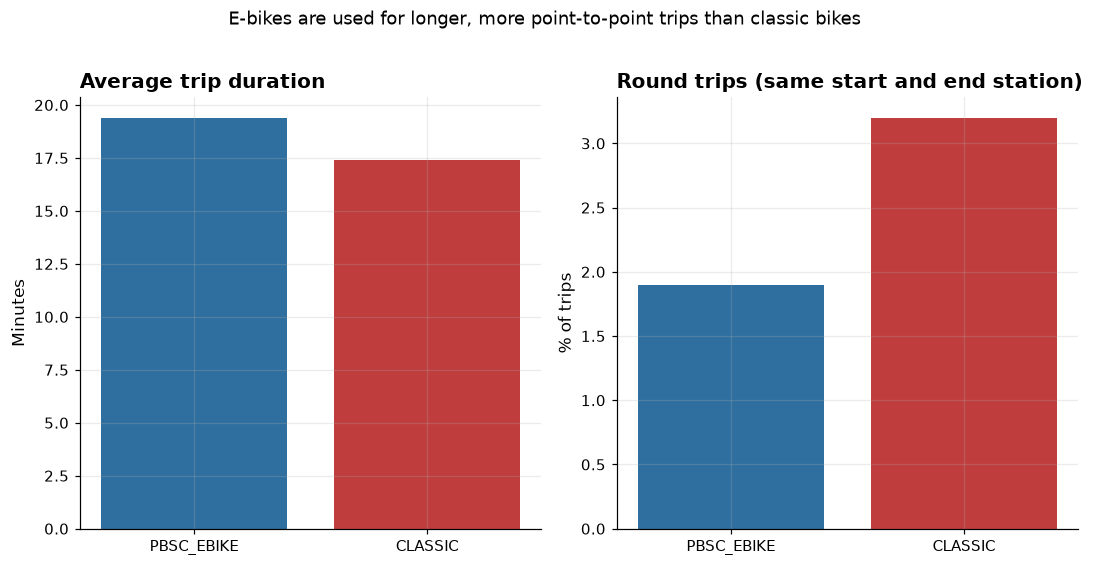

,bike_model,trips,pct_of_trips,avg_duration_min,median_duration_min,round_trips,pct_round_trips
0,PBSC_EBIKE,315908,19.2,19.4,15.8,6011.0,1.9
1,CLASSIC,1331222,80.8,17.4,13.1,42345.0,3.2


In [6]:
fleet = run("05_duration_and_ebike.sql")
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(fleet["bike_model"], fleet["avg_duration_min"], color=[PALETTE[0], PALETTE[3]])
axes[0].set_title("Average trip duration"); axes[0].set_ylabel("Minutes")
axes[1].bar(fleet["bike_model"], fleet["pct_round_trips"], color=[PALETTE[0], PALETTE[3]])
axes[1].set_title("Round trips (same start and end station)"); axes[1].set_ylabel("% of trips")
fig.suptitle("E-bikes are used for longer, more point-to-point trips than classic bikes", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "04_ebike_vs_classic.png")
plt.show()
fleet

**Finding:** e-bikes are already 19.2% of all trips despite being a smaller share of the fleet, average a couple of minutes longer per trip, and are used for a round trip (same start and end station, typical of leisure loops) less than half as often as classic bikes (1.9% vs 3.2%). E-bikes look like they're doing more genuine point-to-point commuting and errands, which is useful context for where to prioritise e-bike availability: the same commute-heavy stations identified in sections 2 and 3, not the leisure-heavy ones.

## Summary

See [`report.md`](../report.md) for the full written analysis, and [`README.md`](../README.md) for the one-page version.